# Evolutionary Algorithms - Exercise 4.2

Setup for permutation-based optimization using Function6


## Setup and Imports


In [55]:
import requests
import numpy as np
from typing import List, Tuple, Callable, Dict, Any
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from itertools import product
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42


In [56]:
class BlackBox:
    """
    Interface to the black-box service for ODM course.
    """
    def __init__(self, token: int, endpoint: str = 'http://ls-stat-ml.uni-muenster.de:7300/'):
        self.endpoint = endpoint
        self.token = token

    def evaluate(self, objective: str, parameters: list) -> float:
        r = requests.post(url=self.endpoint + "compute/" + objective,
                          json={"parameters": [str(v) for v in parameters], "token": self.token})
        if r.status_code == 200:
            return float(r.json())
        else:
            raise ValueError(r)


In [57]:
group_number = 11
bb = BlackBox(token=group_number)

REFERENCE_SOLUTION = list(range(0, 20))
reference_fitness = bb.evaluate("Function6", REFERENCE_SOLUTION)
print(f"Reference solution [0,1,2,...,19] has fitness: {reference_fitness}")


Reference solution [0,1,2,...,19] has fitness: 3498.9338431451583


## Core EA Components


### Population Management


In [58]:
def initialize_population(population_size: int, permutation_length: int = 20) -> List[np.ndarray]:
    """
    Create initial population of random permutations.
    
    Args:
        population_size: Number of individuals in population
        permutation_length: Length of each permutation (default 20 for Function6)
    
    Returns:
        List of numpy arrays, each representing a permutation
    """
    return [np.random.permutation(permutation_length) for _ in range(population_size)]


In [59]:
population = initialize_population(population_size=10)
print(f"Created population with {len(population)} individuals")
print(f"Example individual: {population[0]}")


Created population with 10 individuals
Example individual: [13 14 12  6  1  0  4  9  5  3 19 18  2 11 10 17 15 16  7  8]


### Central Evaluation Function


In [60]:
def evaluate_individual(individual: np.ndarray, blackbox: BlackBox, function_name: str = "Function6") -> float:
    """
    Central evaluation function for a single individual.
    
    Args:
        individual: Permutation to evaluate
        blackbox: BlackBox instance for evaluation
        function_name: Name of the function to evaluate (default: Function6)
    
    Returns:
        Fitness value (lower is better for minimization)
    """
    return blackbox.evaluate(function_name, individual.tolist())


def evaluate_population(population: List[np.ndarray], blackbox: BlackBox, function_name: str = "Function6") -> List[float]:
    """
    Evaluate entire population.
    
    Args:
        population: List of individuals
        blackbox: BlackBox instance for evaluation
        function_name: Name of the function to evaluate
    
    Returns:
        List of fitness values corresponding to each individual
    """
    return [evaluate_individual(ind, blackbox, function_name) for ind in population]


In [61]:
fitness_values = evaluate_population(population, bb)
print(f"Fitness values: {fitness_values}")
print(f"Best fitness in population: {min(fitness_values)}")
print(f"Worst fitness in population: {max(fitness_values)}")


Fitness values: [3115.1694640065175, 3069.486026835639, 3223.371286568574, 2722.4178508226396, 3278.1559434460823, 3714.4196656324148, 3002.752640281124, 3542.5543160125853, 2818.3133713317693, 3262.9652024159714]
Best fitness in population: 2722.4178508226396
Worst fitness in population: 3714.4196656324148


### Selection Operators


In [62]:
def tournament_selection(population: List[np.ndarray], fitness_values: List[float], tournament_size: int = 3) -> np.ndarray:
    """
    Select individual using tournament selection.
    
    Args:
        population: List of individuals
        fitness_values: Corresponding fitness values
        tournament_size: Number of individuals in tournament
    
    Returns:
        Selected individual
    """
    indices = np.random.choice(len(population), size=tournament_size, replace=False)
    tournament_fitness = [fitness_values[i] for i in indices]
    winner_idx = indices[np.argmin(tournament_fitness)]
    return population[winner_idx].copy()


def elite_selection(population: List[np.ndarray], fitness_values: List[float], **kwargs) -> np.ndarray:
    """
    Select best individual from population (elitist selection).
    
    Args:
        population: List of individuals
        fitness_values: Corresponding fitness values
    
    Returns:
        Best individual
    """
    best_idx = np.argmin(fitness_values)
    return population[best_idx].copy()


def roulette_wheel_selection(population: List[np.ndarray], fitness_values: List[float], **kwargs) -> np.ndarray:
    """
    Select individual using fitness-proportional selection (for minimization).
    
    Args:
        population: List of individuals
        fitness_values: Corresponding fitness values
    
    Returns:
        Selected individual
    """
    inverted_fitness = [1.0 / (1.0 + f) for f in fitness_values]
    probabilities = np.array(inverted_fitness) / sum(inverted_fitness)
    selected_idx = np.random.choice(len(population), p=probabilities)
    return population[selected_idx].copy()


### Mutation Operators


In [63]:
def swap_mutation(individual: np.ndarray) -> np.ndarray:
    """
    Swap two random positions in permutation.
    
    Args:
        individual: Permutation to mutate
    
    Returns:
        Mutated permutation
    """
    mutated = individual.copy()
    i, j = np.random.choice(len(mutated), size=2, replace=False)
    mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated


def insert_mutation(individual: np.ndarray) -> np.ndarray:
    """
    Remove element at one position and insert at another.
    
    Args:
        individual: Permutation to mutate
    
    Returns:
        Mutated permutation
    """
    mutated = individual.copy()
    i, j = np.random.choice(len(mutated), size=2, replace=False)
    element = mutated[i]
    mutated = np.delete(mutated, i)
    mutated = np.insert(mutated, j, element)
    return mutated


def inversion_mutation(individual: np.ndarray) -> np.ndarray:
    """
    Reverse a random segment of the permutation.
    
    Args:
        individual: Permutation to mutate
    
    Returns:
        Mutated permutation
    """
    mutated = individual.copy()
    i, j = sorted(np.random.choice(len(mutated), size=2, replace=False))
    mutated[i:j+1] = mutated[i:j+1][::-1]
    return mutated


### Crossover Operators


In [64]:
def order_crossover(parent1: np.ndarray, parent2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Order crossover (OX) for permutations.
    
    Args:
        parent1: First parent permutation
        parent2: Second parent permutation
    
    Returns:
        Tuple of two offspring
    """
    size = len(parent1)
    i, j = sorted(np.random.choice(size, size=2, replace=False))
    
    offspring1 = np.full(size, -1)
    offspring1[i:j+1] = parent1[i:j+1]
    
    offspring2 = np.full(size, -1)
    offspring2[i:j+1] = parent2[i:j+1]
    
    def fill_offspring(offspring, donor):
        pos = (j + 1) % size
        for gene in np.roll(donor, -j-1):
            if gene not in offspring:
                offspring[pos] = gene
                pos = (pos + 1) % size
        return offspring
    
    offspring1 = fill_offspring(offspring1, parent2)
    offspring2 = fill_offspring(offspring2, parent1)
    
    return offspring1, offspring2


def pmx_crossover(parent1: np.ndarray, parent2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Partially Mapped Crossover (PMX) for permutations.
    
    Args:
        parent1: First parent permutation
        parent2: Second parent permutation
    
    Returns:
        Tuple of two offspring
    """
    size = len(parent1)
    i, j = sorted(np.random.choice(size, size=2, replace=False))
    
    offspring1 = parent1.copy()
    offspring2 = parent2.copy()
    
    for k in range(i, j+1):
        val1, val2 = offspring1[k], offspring2[k]
        offspring1[k], offspring2[k] = val2, val1
        
        idx1 = np.where(offspring1 == val2)[0]
        idx2 = np.where(offspring2 == val1)[0]
        
        if len(idx1) > 1:
            other_idx = idx1[idx1 != k][0]
            offspring1[other_idx] = val1
            
        if len(idx2) > 1:
            other_idx = idx2[idx2 != k][0]
            offspring2[other_idx] = val2
    
    return offspring1, offspring2


### Circular Crossover (for Exercise 4.2)


In [65]:
def circular_crossover(parent1: np.ndarray, parent2: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Circular crossover for permutations.
    
    Selects a random segment from one parent and fills remaining positions
    by iterating circularly through the other parent, only including elements
    not yet present in the offspring.
    
    Args:
        parent1: First parent permutation
        parent2: Second parent permutation
    
    Returns:
        Tuple of two offspring
    """
    size = len(parent1)
    i, j = sorted(np.random.choice(size, size=2, replace=False))
    
    offspring1 = np.full(size, -1)
    offspring2 = np.full(size, -1)
    
    offspring1[i:j+1] = parent1[i:j+1]
    offspring2[i:j+1] = parent2[i:j+1]
    
    def fill_circular(offspring, donor, start_pos):
        used = set(offspring[offspring != -1])
        current_pos = (start_pos + 1) % size
        donor_pos = (start_pos + 1) % size
        
        while -1 in offspring:
            if donor[donor_pos] not in used:
                offspring[current_pos] = donor[donor_pos]
                used.add(donor[donor_pos])
                current_pos = (current_pos + 1) % size
            donor_pos = (donor_pos + 1) % size
        
        return offspring
    
    offspring1 = fill_circular(offspring1, parent2, j)
    offspring2 = fill_circular(offspring2, parent1, j)
    
    return offspring1, offspring2


## Evolutionary Algorithm Framework


In [66]:
def evolutionary_algorithm(
    blackbox: BlackBox,
    population_size: int,
    generations: int,
    mutation_rate: float = 0.1,
    crossover_rate: float = 0.8,
    tournament_size: int = 3,
    mutation_operator: Callable = swap_mutation,
    crossover_operator: Callable = order_crossover,
    selection_operator: Callable = tournament_selection,
    permutation_length: int = 20,
    seed: int = None,
    verbose: bool = True
) -> Tuple[np.ndarray, float, List[float]]:
    """
    Generic evolutionary algorithm framework for permutation problems.
    
    Args:
        blackbox: BlackBox instance for evaluation
        population_size: Size of population
        generations: Number of generations to evolve
        mutation_rate: Probability of mutation
        crossover_rate: Probability of crossover
        tournament_size: Size for tournament selection
        mutation_operator: Function for mutation
        crossover_operator: Function for crossover
        selection_operator: Function for selection
        permutation_length: Length of permutations
        seed: Random seed for reproducibility
        verbose: Print progress information
    
    Returns:
        Tuple of (best_individual, best_fitness, fitness_history)
    """
    if seed is not None:
        np.random.seed(seed)
    
    population = initialize_population(population_size, permutation_length)
    fitness_values = evaluate_population(population, blackbox)
    
    best_idx = np.argmin(fitness_values)
    best_individual = population[best_idx].copy()
    best_fitness = fitness_values[best_idx]
    
    fitness_history = [best_fitness]
    
    for generation in range(generations):
        new_population = []
        
        while len(new_population) < population_size:
            if np.random.random() < crossover_rate:
                parent1 = selection_operator(population, fitness_values, tournament_size=tournament_size)
                parent2 = selection_operator(population, fitness_values, tournament_size=tournament_size)
                
                offspring1, offspring2 = crossover_operator(parent1, parent2)
                new_population.extend([offspring1, offspring2])
            else:
                parent = selection_operator(population, fitness_values, tournament_size=tournament_size)
                new_population.append(parent)
        
        new_population = new_population[:population_size]
        
        for i in range(len(new_population)):
            if np.random.random() < mutation_rate:
                new_population[i] = mutation_operator(new_population[i])
        
        population = new_population
        fitness_values = evaluate_population(population, blackbox)
        
        current_best_idx = np.argmin(fitness_values)
        current_best_fitness = fitness_values[current_best_idx]
        
        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_individual = population[current_best_idx].copy()
        
        fitness_history.append(best_fitness)
        
        if verbose and (generation + 1) % 10 == 0:
            avg_fitness = np.mean(fitness_values)
            print(f"Generation {generation + 1}/{generations}: Best={best_fitness:.4f}, Avg={avg_fitness:.4f}")
    
    return best_individual, best_fitness, fitness_history


## Comprehensive Grid Search Experiments

Systematic evaluation of all operator combinations and hyperparameters
.8

In [ ]:
POPULATION_SIZE = 30
GENERATIONS = 50

CROSSOVER_OPERATORS = {
    "Order": order_crossover,
    "PMX": pmx_crossover,
    "Circular": circular_crossover,
}

MUTATION_OPERATORS = {
    "Swap": swap_mutation,
    "Insert": insert_mutation,
    "Inversion": inversion_mutation,
}

SELECTION_OPERATORS = {
    "Tournament": tournament_selection,
    "Roulette": roulette_wheel_selection,
    "Elite": elite_selection,
}

MUTATION_RATES = [0.1, 0.2]
CROSSOVER_RATES = [0.7, 0.8]

print(f"Experiment Configuration:")
print(f"  Population Size: {POPULATION_SIZE}")
print(f"  Generations: {GENERATIONS}")
print(f"  Random Seed: {RANDOM_SEED}")
print(f"\nOperators to test:")
print(f"  Crossover: {list(CROSSOVER_OPERATORS.keys())}")
print(f"  Mutation: {list(MUTATION_OPERATORS.keys())}")
print(f"  Selection: {list(SELECTION_OPERATORS.keys())}")
print(f"\nHyperparameters to test:")
print(f"  Mutation Rates: {MUTATION_RATES}")
print(f"  Crossover Rates: {CROSSOVER_RATES}")
print(f"\nTotal experiments: {len(CROSSOVER_OPERATORS) * len(MUTATION_OPERATORS) * len(SELECTION_OPERATORS) * len(MUTATION_RATES) * len(CROSSOVER_RATES)}")
print(f"\nEstimated runtime: ~{len(CROSSOVER_OPERATORS) * len(MUTATION_OPERATORS) * len(SELECTION_OPERATORS) * len(MUTATION_RATES) * len(CROSSOVER_RATES) * 2:.0f} minutes (~{len(CROSSOVER_OPERATORS) * len(MUTATION_OPERATORS) * len(SELECTION_OPERATORS) * len(MUTATION_RATES) * len(CROSSOVER_RATES) * 2 / 60:.1f} hours)")


Experiment Configuration:
  Population Size: 30
  Generations: 50
  Random Seed: 42

Operators to test:
  Crossover: ['Order', 'PMX', 'Circular']
  Mutation: ['Swap', 'Insert', 'Inversion']
  Selection: ['Tournament', 'Roulette', 'Elite']

Hyperparameters to test:
  Mutation Rates: [0.1, 0.2]
  Crossover Rates: [0.7, 0.8]

Total experiments: 108

Estimated runtime: ~216 minutes (~3.6 hours)


In [68]:
def run_grid_search(
    blackbox: BlackBox,
    crossover_operators: Dict[str, Callable],
    mutation_operators: Dict[str, Callable],
    selection_operators: Dict[str, Callable],
    mutation_rates: List[float],
    crossover_rates: List[float],
    population_size: int,
    generations: int,
    seed: int = RANDOM_SEED,
    verbose: bool = False
) -> pd.DataFrame:
    """
    Run complete grid search over all operator and hyperparameter combinations.
    
    Args:
        blackbox: BlackBox instance for evaluation
        crossover_operators: Dictionary of crossover operators
        mutation_operators: Dictionary of mutation operators
        selection_operators: Dictionary of selection operators
        mutation_rates: List of mutation rates to test
        crossover_rates: List of crossover rates to test
        population_size: Population size (fixed)
        generations: Number of generations (fixed)
        seed: Random seed for reproducibility
        verbose: Print progress information
    
    Returns:
        DataFrame with all experiment results
    """
    results = []
    total_experiments = (len(crossover_operators) * len(mutation_operators) * 
                        len(selection_operators) * len(mutation_rates) * len(crossover_rates))
    experiment_num = 0
    
    for (cross_name, cross_op), (mut_name, mut_op), (sel_name, sel_op), mut_rate, cross_rate in product(
        crossover_operators.items(),
        mutation_operators.items(),
        selection_operators.items(),
        mutation_rates,
        crossover_rates
    ):
        experiment_num += 1
        
        if verbose or experiment_num % 10 == 0:
            print(f"Running experiment {experiment_num}/{total_experiments}: "
                  f"Cross={cross_name}, Mut={mut_name}, Sel={sel_name}, "
                  f"MR={mut_rate}, CR={cross_rate}")
        
        best_ind, best_fit, history = evolutionary_algorithm(
            blackbox=blackbox,
            population_size=population_size,
            generations=generations,
            mutation_rate=mut_rate,
            crossover_rate=cross_rate,
            mutation_operator=mut_op,
            crossover_operator=cross_op,
            selection_operator=sel_op,
            seed=seed,
            verbose=False
        )
        
        results.append({
            'crossover': cross_name,
            'mutation': mut_name,
            'selection': sel_name,
            'mutation_rate': mut_rate,
            'crossover_rate': cross_rate,
            'best_fitness': best_fit,
            'final_fitness': history[-1],
            'improvement': reference_fitness - best_fit,
            'history': history,
            'best_solution': best_ind
        })
    
    return pd.DataFrame(results)

print("\nRunning comprehensive grid search...")
print("This may take a while...")

results_df = run_grid_search(
    blackbox=bb,
    crossover_operators=CROSSOVER_OPERATORS,
    mutation_operators=MUTATION_OPERATORS,
    selection_operators=SELECTION_OPERATORS,
    mutation_rates=MUTATION_RATES,
    crossover_rates=CROSSOVER_RATES,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    seed=RANDOM_SEED,
    verbose=True
)

print(f"\n{'='*60}")
print("Grid search completed!")
print(f"Total experiments run: {len(results_df)}")
print(f"{'='*60}")



Running comprehensive grid search...
This may take a while...
Running experiment 1/108: Cross=Order, Mut=Swap, Sel=Tournament, MR=0.1, CR=0.7
Running experiment 2/108: Cross=Order, Mut=Swap, Sel=Tournament, MR=0.1, CR=0.8
Running experiment 3/108: Cross=Order, Mut=Swap, Sel=Tournament, MR=0.2, CR=0.7
Running experiment 4/108: Cross=Order, Mut=Swap, Sel=Tournament, MR=0.2, CR=0.8
Running experiment 5/108: Cross=Order, Mut=Swap, Sel=Roulette, MR=0.1, CR=0.7
Running experiment 6/108: Cross=Order, Mut=Swap, Sel=Roulette, MR=0.1, CR=0.8
Running experiment 7/108: Cross=Order, Mut=Swap, Sel=Roulette, MR=0.2, CR=0.7
Running experiment 8/108: Cross=Order, Mut=Swap, Sel=Roulette, MR=0.2, CR=0.8
Running experiment 9/108: Cross=Order, Mut=Swap, Sel=Elite, MR=0.1, CR=0.7
Running experiment 10/108: Cross=Order, Mut=Swap, Sel=Elite, MR=0.1, CR=0.8
Running experiment 11/108: Cross=Order, Mut=Swap, Sel=Elite, MR=0.2, CR=0.7
Running experiment 12/108: Cross=Order, Mut=Swap, Sel=Elite, MR=0.2, CR=0.8
Ru

## Analysis and Visualization

Comprehensive analysis of the grid search results


In [69]:
### Best Results Summary


In [70]:
top_10 = results_df.nsmallest(10, 'best_fitness')

print("="*80)
print("TOP 10 BEST CONFIGURATIONS")
print("="*80)
print(f"\nReference Fitness: {reference_fitness:.4f}\n")

for idx, (i, row) in enumerate(top_10.iterrows(), 1):
    print(f"{idx}. Fitness: {row['best_fitness']:.4f} (Improvement: {row['improvement']:.4f})")
    print(f"   Crossover: {row['crossover']}, Mutation: {row['mutation']}, Selection: {row['selection']}")
    print(f"   Mutation Rate: {row['mutation_rate']}, Crossover Rate: {row['crossover_rate']}")
    print()

best_config = top_10.iloc[0]
print("="*80)
print("BEST OVERALL CONFIGURATION:")
print("="*80)
print(f"Fitness: {best_config['best_fitness']:.4f}")
print(f"Improvement over reference: {best_config['improvement']:.4f}")
print(f"Crossover Operator: {best_config['crossover']}")
print(f"Mutation Operator: {best_config['mutation']}")
print(f"Selection Operator: {best_config['selection']}")
print(f"Mutation Rate: {best_config['mutation_rate']}")
print(f"Crossover Rate: {best_config['crossover_rate']}")
print(f"Best Solution: {best_config['best_solution']}")
print("="*80)


TOP 10 BEST CONFIGURATIONS

Reference Fitness: 3498.9338

1. Fitness: 1300.7856 (Improvement: 2198.1482)
   Crossover: Order, Mutation: Inversion, Selection: Elite
   Mutation Rate: 0.2, Crossover Rate: 0.7

2. Fitness: 1300.7856 (Improvement: 2198.1482)
   Crossover: PMX, Mutation: Inversion, Selection: Elite
   Mutation Rate: 0.2, Crossover Rate: 0.7

3. Fitness: 1300.7856 (Improvement: 2198.1482)
   Crossover: Circular, Mutation: Inversion, Selection: Elite
   Mutation Rate: 0.2, Crossover Rate: 0.7

4. Fitness: 1339.2199 (Improvement: 2159.7140)
   Crossover: Order, Mutation: Inversion, Selection: Tournament
   Mutation Rate: 0.1, Crossover Rate: 0.8

5. Fitness: 1339.2199 (Improvement: 2159.7140)
   Crossover: Circular, Mutation: Inversion, Selection: Tournament
   Mutation Rate: 0.1, Crossover Rate: 0.8

6. Fitness: 1365.8659 (Improvement: 2133.0680)
   Crossover: Order, Mutation: Inversion, Selection: Elite
   Mutation Rate: 0.1, Crossover Rate: 0.8

7. Fitness: 1365.8659 (Impro

### 1. Operator Comparison


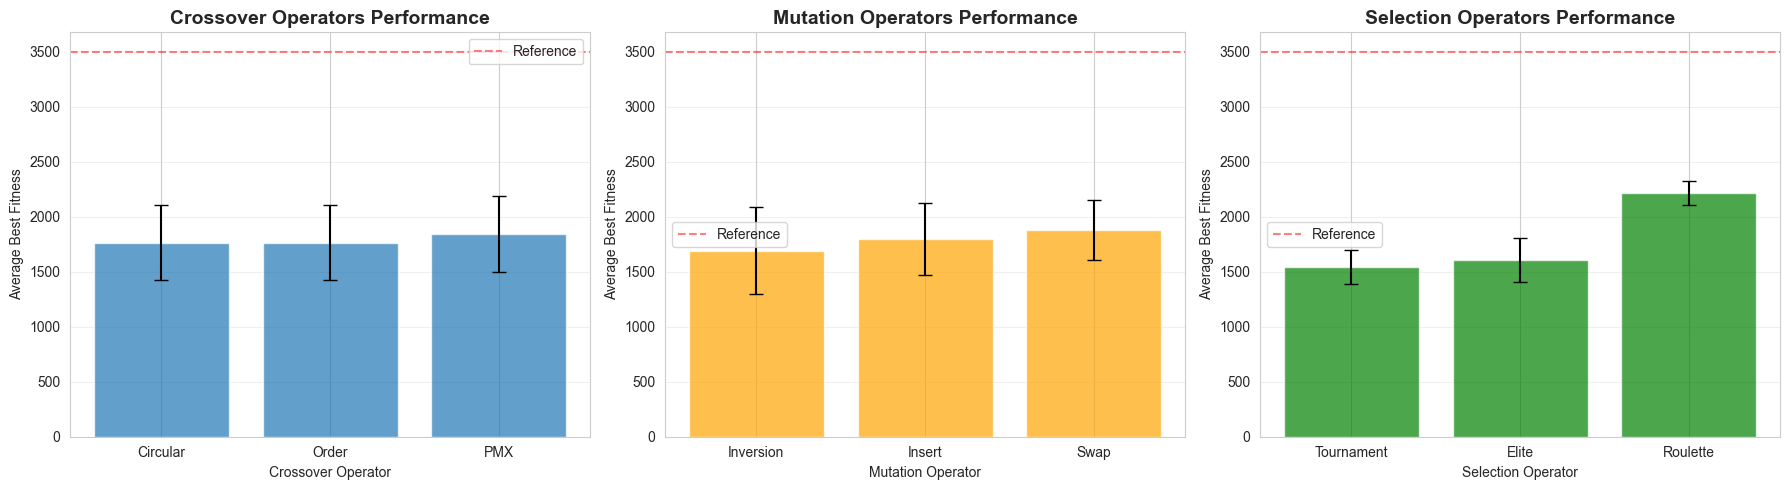


Operator Performance Summary:

Crossover Operators (lower is better):
                  mean         std          min
crossover                                      
Circular   1761.254020  341.554077  1300.785646
Order      1761.254020  341.554077  1300.785646
PMX        1839.022612  344.819142  1300.785646

Mutation Operators (lower is better):
                  mean         std          min
mutation                                       
Inversion  1691.530032  396.640903  1300.785646
Insert     1793.280987  327.590227  1386.636753
Swap       1876.719634  272.087135  1432.516494

Selection Operators (lower is better):
                   mean         std          min
selection                                       
Tournament  1541.355922  154.700484  1339.219886
Elite       1608.710405  200.751438  1300.785646
Roulette    2211.464326  109.792521  2017.758534


In [71]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

crossover_perf = results_df.groupby('crossover')['best_fitness'].agg(['mean', 'std', 'min'])
crossover_perf = crossover_perf.sort_values('mean')
axes[0].bar(crossover_perf.index, crossover_perf['mean'], yerr=crossover_perf['std'], capsize=5, alpha=0.7)
axes[0].axhline(y=reference_fitness, color='r', linestyle='--', label='Reference', alpha=0.5)
axes[0].set_title('Crossover Operators Performance', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Best Fitness')
axes[0].set_xlabel('Crossover Operator')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

mutation_perf = results_df.groupby('mutation')['best_fitness'].agg(['mean', 'std', 'min'])
mutation_perf = mutation_perf.sort_values('mean')
axes[1].bar(mutation_perf.index, mutation_perf['mean'], yerr=mutation_perf['std'], capsize=5, alpha=0.7, color='orange')
axes[1].axhline(y=reference_fitness, color='r', linestyle='--', label='Reference', alpha=0.5)
axes[1].set_title('Mutation Operators Performance', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Best Fitness')
axes[1].set_xlabel('Mutation Operator')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

selection_perf = results_df.groupby('selection')['best_fitness'].agg(['mean', 'std', 'min'])
selection_perf = selection_perf.sort_values('mean')
axes[2].bar(selection_perf.index, selection_perf['mean'], yerr=selection_perf['std'], capsize=5, alpha=0.7, color='green')
axes[2].axhline(y=reference_fitness, color='r', linestyle='--', label='Reference', alpha=0.5)
axes[2].set_title('Selection Operators Performance', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Average Best Fitness')
axes[2].set_xlabel('Selection Operator')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOperator Performance Summary:")
print("\nCrossover Operators (lower is better):")
print(crossover_perf)
print("\nMutation Operators (lower is better):")
print(mutation_perf)
print("\nSelection Operators (lower is better):")
print(selection_perf)


### 2. Hyperparameter Analysis


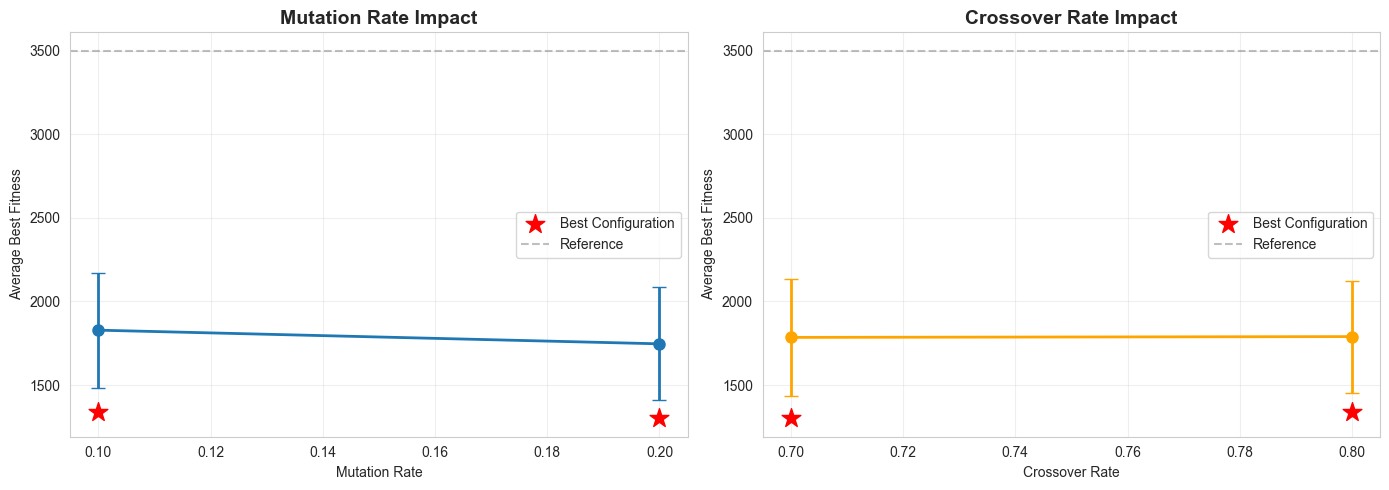


Hyperparameter Performance Summary:

Mutation Rates (lower is better):
                      mean         std          min
mutation_rate                                      
0.1            1828.025427  343.263354  1339.219886
0.2            1746.328341  337.795785  1300.785646

Crossover Rates (lower is better):
                       mean         std          min
crossover_rate                                      
0.7             1784.761612  350.499288  1300.785646
0.8             1789.592156  335.371819  1339.219886


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mutation_rate_perf = results_df.groupby('mutation_rate')['best_fitness'].agg(['mean', 'std', 'min'])
axes[0].errorbar(mutation_rate_perf.index, mutation_rate_perf['mean'], 
                 yerr=mutation_rate_perf['std'], marker='o', capsize=5, linewidth=2, markersize=8)
axes[0].scatter(mutation_rate_perf.index, mutation_rate_perf['min'], color='red', 
                marker='*', s=200, label='Best Configuration', zorder=5)
axes[0].axhline(y=reference_fitness, color='gray', linestyle='--', label='Reference', alpha=0.5)
axes[0].set_title('Mutation Rate Impact', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Best Fitness')
axes[0].set_xlabel('Mutation Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

crossover_rate_perf = results_df.groupby('crossover_rate')['best_fitness'].agg(['mean', 'std', 'min'])
axes[1].errorbar(crossover_rate_perf.index, crossover_rate_perf['mean'], 
                 yerr=crossover_rate_perf['std'], marker='o', capsize=5, linewidth=2, markersize=8, color='orange')
axes[1].scatter(crossover_rate_perf.index, crossover_rate_perf['min'], color='red', 
                marker='*', s=200, label='Best Configuration', zorder=5)
axes[1].axhline(y=reference_fitness, color='gray', linestyle='--', label='Reference', alpha=0.5)
axes[1].set_title('Crossover Rate Impact', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Best Fitness')
axes[1].set_xlabel('Crossover Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHyperparameter Performance Summary:")
print("\nMutation Rates (lower is better):")
print(mutation_rate_perf)
print("\nCrossover Rates (lower is better):")
print(crossover_rate_perf)


### 3. Heatmap Analysis - Operator Interactions


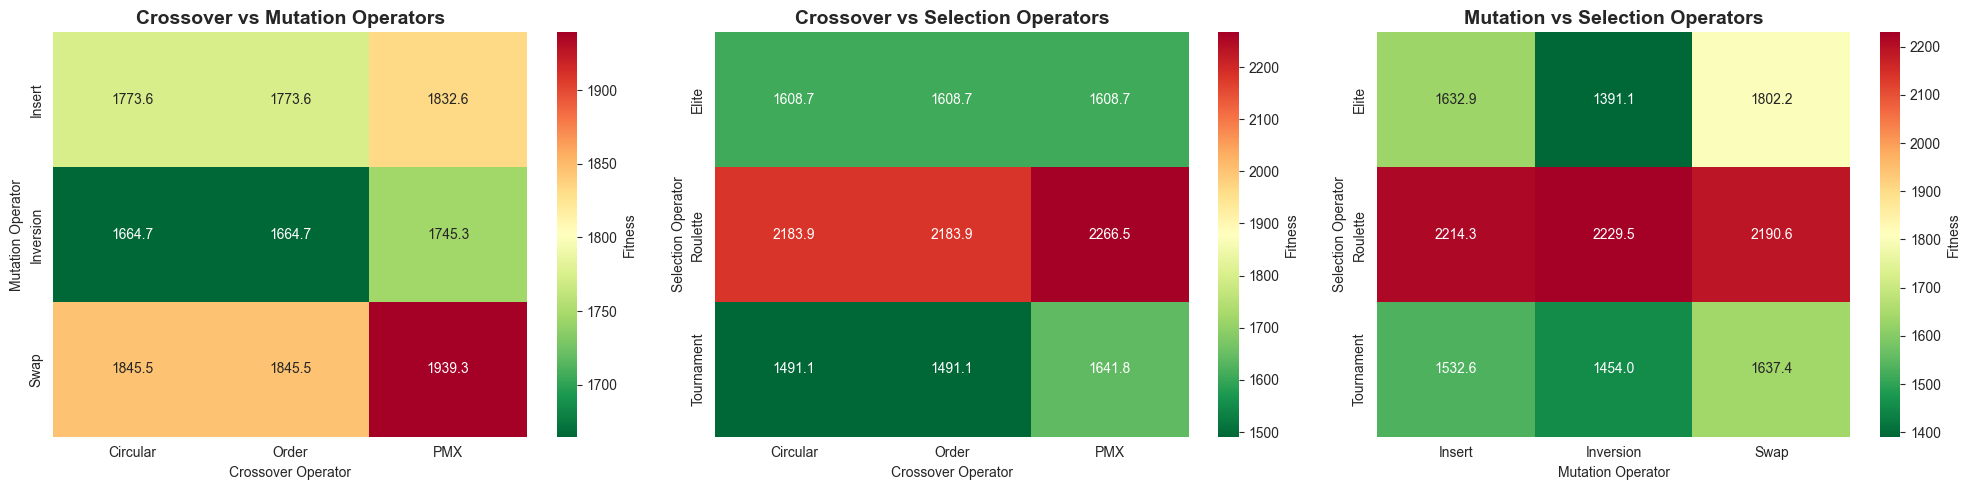


Interaction Analysis:

Crossover x Mutation:
crossover     Circular        Order          PMX
mutation                                        
Insert     1773.644608  1773.644608  1832.553743
Inversion  1664.664407  1664.664407  1745.261283
Swap       1845.453045  1845.453045  1939.252811

Crossover x Selection:
crossover      Circular        Order          PMX
selection                                        
Elite       1608.710405  1608.710405  1608.710405
Roulette    2183.930760  2183.930760  2266.531456
Tournament  1491.120895  1491.120895  1641.825976

Mutation x Selection:
mutation         Insert    Inversion         Swap
selection                                        
Elite       1632.896721  1391.082828  1802.151666
Roulette    2214.304095  2229.479201  2190.609681
Tournament  1532.642144  1454.028068  1637.397554


In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

crossover_mutation = results_df.pivot_table(
    values='best_fitness', index='mutation', columns='crossover', aggfunc='mean'
)
sns.heatmap(crossover_mutation, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[0], cbar_kws={'label': 'Fitness'})
axes[0].set_title('Crossover vs Mutation Operators', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Crossover Operator')
axes[0].set_ylabel('Mutation Operator')

crossover_selection = results_df.pivot_table(
    values='best_fitness', index='selection', columns='crossover', aggfunc='mean'
)
sns.heatmap(crossover_selection, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'Fitness'})
axes[1].set_title('Crossover vs Selection Operators', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Crossover Operator')
axes[1].set_ylabel('Selection Operator')

mutation_selection = results_df.pivot_table(
    values='best_fitness', index='selection', columns='mutation', aggfunc='mean'
)
sns.heatmap(mutation_selection, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=axes[2], cbar_kws={'label': 'Fitness'})
axes[2].set_title('Mutation vs Selection Operators', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Mutation Operator')
axes[2].set_ylabel('Selection Operator')

plt.tight_layout()
plt.show()

print("\nInteraction Analysis:")
print("\nCrossover x Mutation:")
print(crossover_mutation)
print("\nCrossover x Selection:")
print(crossover_selection)
print("\nMutation x Selection:")
print(mutation_selection)


### 4. Convergence Analysis - Top Configurations


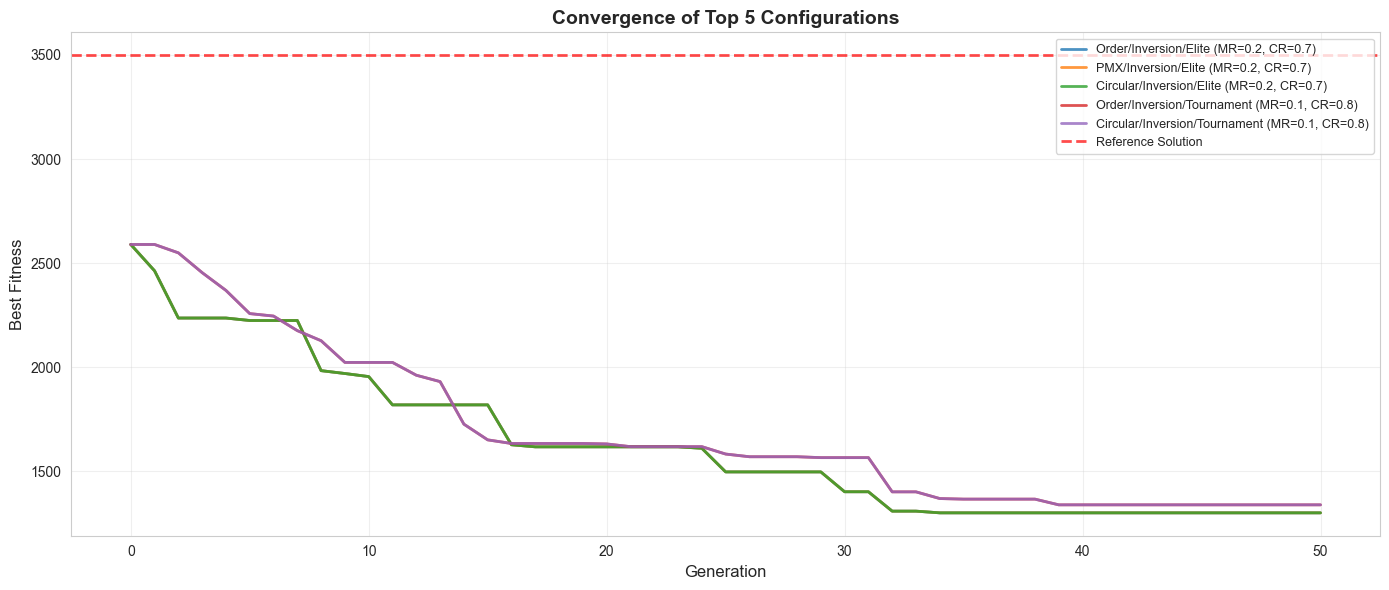


Convergence Statistics for Top 5:

1. Order/Inversion/Elite
   Initial: 2589.84 → Final: 1300.79
   Total Improvement: 1289.05 (49.8%)

2. PMX/Inversion/Elite
   Initial: 2589.84 → Final: 1300.79
   Total Improvement: 1289.05 (49.8%)

3. Circular/Inversion/Elite
   Initial: 2589.84 → Final: 1300.79
   Total Improvement: 1289.05 (49.8%)

4. Order/Inversion/Tournament
   Initial: 2589.84 → Final: 1339.22
   Total Improvement: 1250.62 (48.3%)

5. Circular/Inversion/Tournament
   Initial: 2589.84 → Final: 1339.22
   Total Improvement: 1250.62 (48.3%)


In [74]:
plt.figure(figsize=(14, 6))

top_5 = results_df.nsmallest(5, 'best_fitness')

for idx, (i, row) in enumerate(top_5.iterrows()):
    label = f"{row['crossover']}/{row['mutation']}/{row['selection']} (MR={row['mutation_rate']}, CR={row['crossover_rate']})"
    plt.plot(row['history'], linewidth=2, label=label, alpha=0.8)

plt.axhline(y=reference_fitness, color='red', linestyle='--', linewidth=2, label='Reference Solution', alpha=0.7)

plt.xlabel('Generation', fontsize=12)
plt.ylabel('Best Fitness', fontsize=12)
plt.title('Convergence of Top 5 Configurations', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConvergence Statistics for Top 5:")
for idx, (i, row) in enumerate(top_5.iterrows(), 1):
    history = row['history']
    initial_fitness = history[0]
    final_fitness = history[-1]
    improvement = initial_fitness - final_fitness
    print(f"\n{idx}. {row['crossover']}/{row['mutation']}/{row['selection']}")
    print(f"   Initial: {initial_fitness:.2f} → Final: {final_fitness:.2f}")
    print(f"   Total Improvement: {improvement:.2f} ({improvement/initial_fitness*100:.1f}%)")


### 5. Statistical Distribution of Results


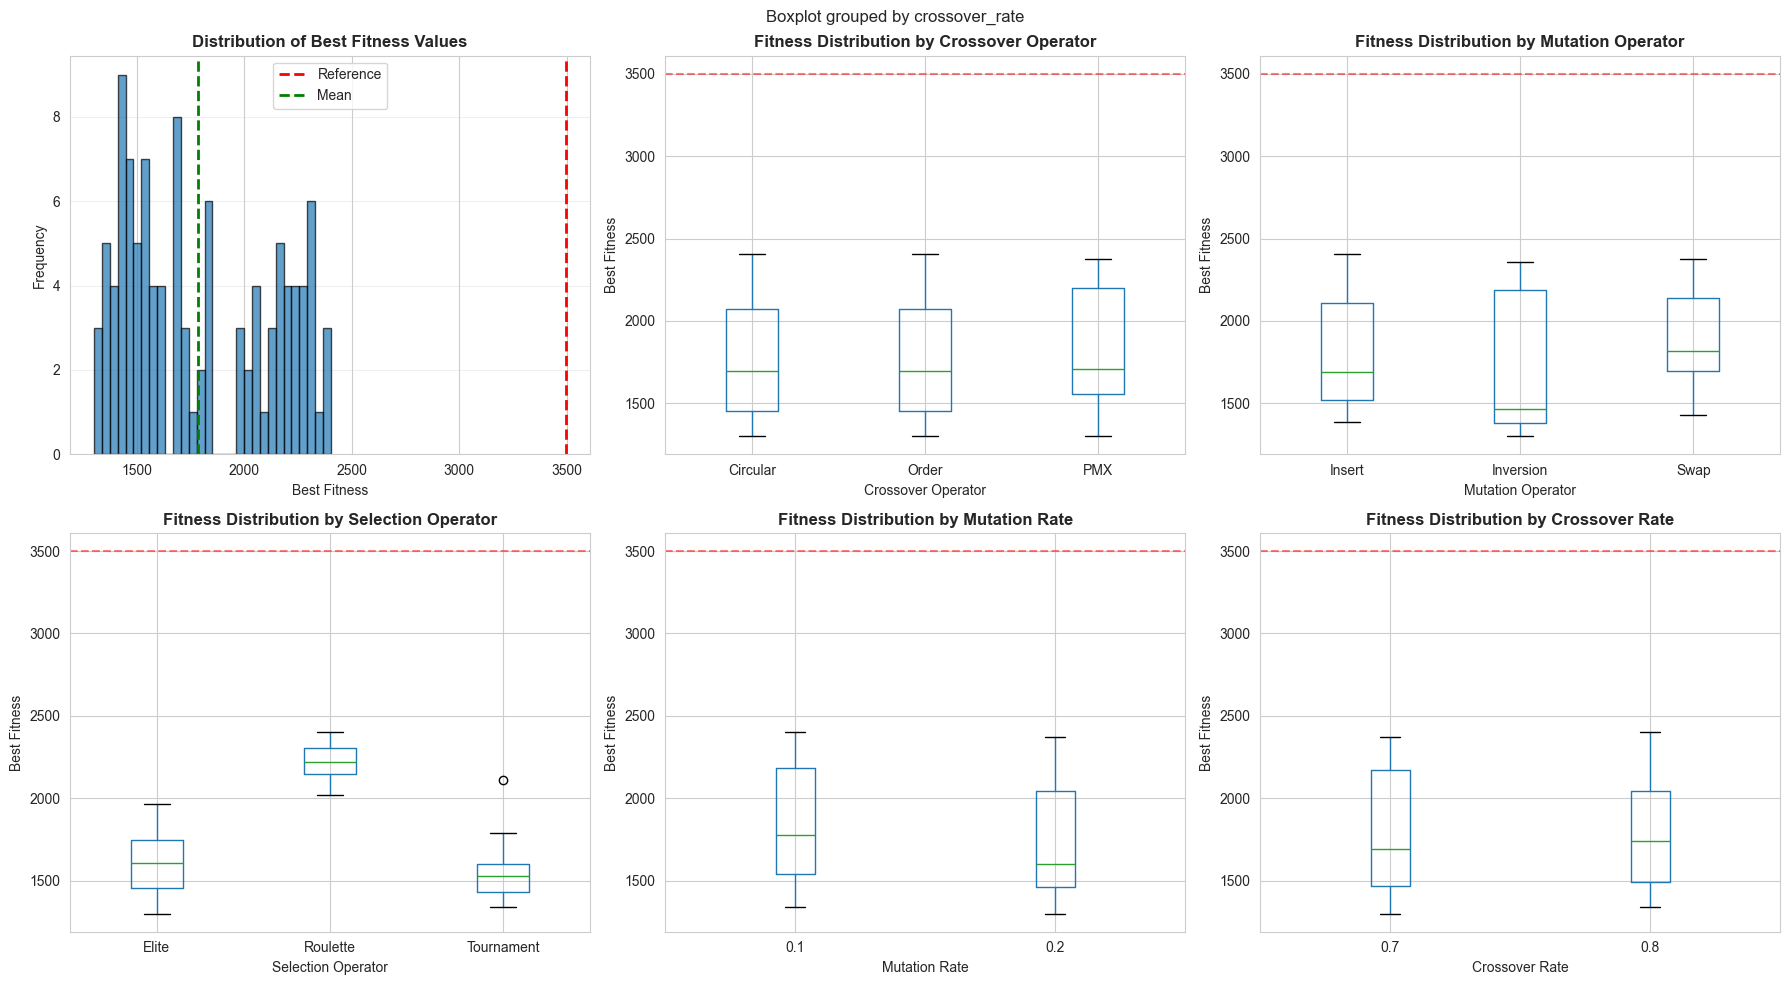


Statistical Summary:
Mean Best Fitness: 1787.18
Median Best Fitness: 1699.84
Std Dev: 341.42
Min: 1300.79
Max: 2403.68
Reference Fitness: 3498.93


In [75]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].hist(results_df['best_fitness'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(x=reference_fitness, color='red', linestyle='--', linewidth=2, label='Reference')
axes[0, 0].axvline(x=results_df['best_fitness'].mean(), color='green', linestyle='--', linewidth=2, label='Mean')
axes[0, 0].set_xlabel('Best Fitness')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Best Fitness Values', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

results_df.boxplot(column='best_fitness', by='crossover', ax=axes[0, 1])
axes[0, 1].set_title('Fitness Distribution by Crossover Operator', fontweight='bold')
axes[0, 1].set_xlabel('Crossover Operator')
axes[0, 1].set_ylabel('Best Fitness')
axes[0, 1].axhline(y=reference_fitness, color='red', linestyle='--', alpha=0.5)
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

results_df.boxplot(column='best_fitness', by='mutation', ax=axes[0, 2])
axes[0, 2].set_title('Fitness Distribution by Mutation Operator', fontweight='bold')
axes[0, 2].set_xlabel('Mutation Operator')
axes[0, 2].set_ylabel('Best Fitness')
axes[0, 2].axhline(y=reference_fitness, color='red', linestyle='--', alpha=0.5)
plt.sca(axes[0, 2])
plt.xticks(rotation=0)

results_df.boxplot(column='best_fitness', by='selection', ax=axes[1, 0])
axes[1, 0].set_title('Fitness Distribution by Selection Operator', fontweight='bold')
axes[1, 0].set_xlabel('Selection Operator')
axes[1, 0].set_ylabel('Best Fitness')
axes[1, 0].axhline(y=reference_fitness, color='red', linestyle='--', alpha=0.5)
plt.sca(axes[1, 0])
plt.xticks(rotation=0)

results_df.boxplot(column='best_fitness', by='mutation_rate', ax=axes[1, 1])
axes[1, 1].set_title('Fitness Distribution by Mutation Rate', fontweight='bold')
axes[1, 1].set_xlabel('Mutation Rate')
axes[1, 1].set_ylabel('Best Fitness')
axes[1, 1].axhline(y=reference_fitness, color='red', linestyle='--', alpha=0.5)

results_df.boxplot(column='best_fitness', by='crossover_rate', ax=axes[1, 2])
axes[1, 2].set_title('Fitness Distribution by Crossover Rate', fontweight='bold')
axes[1, 2].set_xlabel('Crossover Rate')
axes[1, 2].set_ylabel('Best Fitness')
axes[1, 2].axhline(y=reference_fitness, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nStatistical Summary:")
print(f"Mean Best Fitness: {results_df['best_fitness'].mean():.2f}")
print(f"Median Best Fitness: {results_df['best_fitness'].median():.2f}")
print(f"Std Dev: {results_df['best_fitness'].std():.2f}")
print(f"Min: {results_df['best_fitness'].min():.2f}")
print(f"Max: {results_df['best_fitness'].max():.2f}")
print(f"Reference Fitness: {reference_fitness:.2f}")


### 6. Summary Tables and Recommendations


In [76]:
summary_stats = results_df.groupby(['crossover', 'mutation', 'selection']).agg({
    'best_fitness': ['mean', 'std', 'min', 'max'],
    'improvement': 'mean'
}).round(2)

summary_stats.columns = ['Mean Fitness', 'Std Dev', 'Best', 'Worst', 'Avg Improvement']
summary_stats = summary_stats.sort_values('Best')

print("="*100)
print("COMPREHENSIVE OPERATOR COMBINATION RANKING")
print("="*100)
print("\nTop 10 Operator Combinations (sorted by best achieved fitness):")
print(summary_stats.head(10))

print("\n" + "="*100)
print("RECOMMENDATIONS FOR FUNCTION6 OPTIMIZATION")
print("="*100)

best_crossover = crossover_perf.loc[crossover_perf['mean'].idxmin()]
best_mutation = mutation_perf.loc[mutation_perf['mean'].idxmin()]
best_selection = selection_perf.loc[selection_perf['mean'].idxmin()]
best_mut_rate = mutation_rate_perf.loc[mutation_rate_perf['mean'].idxmin()]
best_cross_rate = crossover_rate_perf.loc[crossover_rate_perf['mean'].idxmin()]

print(f"\n1. BEST CROSSOVER OPERATOR:")
print(f"   → {best_crossover.name}")
print(f"   Average Fitness: {best_crossover['mean']:.2f} (±{best_crossover['std']:.2f})")

print(f"\n2. BEST MUTATION OPERATOR:")
print(f"   → {best_mutation.name}")
print(f"   Average Fitness: {best_mutation['mean']:.2f} (±{best_mutation['std']:.2f})")

print(f"\n3. BEST SELECTION OPERATOR:")
print(f"   → {best_selection.name}")
print(f"   Average Fitness: {best_selection['mean']:.2f} (±{best_selection['std']:.2f})")

print(f"\n4. BEST MUTATION RATE:")
print(f"   → {best_mut_rate.name}")
print(f"   Average Fitness: {best_mut_rate['mean']:.2f} (±{best_mut_rate['std']:.2f})")

print(f"\n5. BEST CROSSOVER RATE:")
print(f"   → {best_cross_rate.name}")
print(f"   Average Fitness: {best_cross_rate['mean']:.2f} (±{best_cross_rate['std']:.2f})")

print(f"\n6. OVERALL BEST CONFIGURATION:")
print(f"   Crossover: {best_config['crossover']}")
print(f"   Mutation: {best_config['mutation']}")
print(f"   Selection: {best_config['selection']}")
print(f"   Mutation Rate: {best_config['mutation_rate']}")
print(f"   Crossover Rate: {best_config['crossover_rate']}")
print(f"   Achieved Fitness: {best_config['best_fitness']:.2f}")
print(f"   Improvement: {best_config['improvement']:.2f} ({best_config['improvement']/reference_fitness*100:.1f}%)")

print("\n" + "="*100)


COMPREHENSIVE OPERATOR COMBINATION RANKING

Top 10 Operator Combinations (sorted by best achieved fitness):
                                Mean Fitness  Std Dev     Best    Worst  \
crossover mutation  selection                                             
Circular  Inversion Elite            1391.08    73.25  1300.79  1466.66   
PMX       Inversion Elite            1391.08    73.25  1300.79  1466.66   
Order     Inversion Elite            1391.08    73.25  1300.79  1466.66   
Circular  Inversion Tournament       1406.29    56.33  1339.22  1458.25   
Order     Inversion Tournament       1406.29    56.33  1339.22  1458.25   
Circular  Insert    Tournament       1476.03    87.36  1386.64  1579.71   
Order     Insert    Tournament       1476.03    87.36  1386.64  1579.71   
          Swap      Tournament       1591.04   149.21  1432.52  1789.31   
Circular  Swap      Tournament       1591.04   149.21  1432.52  1789.31   
PMX       Inversion Tournament       1549.51    98.50  1471.61  168

### 7. Export Results (Optional)


In [77]:
results_export = results_df.drop(columns=['history', 'best_solution']).copy()

print("Results DataFrame (without history and solution arrays):")
print(results_export.head(10))
print(f"\nTotal experiments: {len(results_export)}")
print(f"\nTo save results, uncomment the line below:")
print("# results_export.to_csv('ea_grid_search_results.csv', index=False)")


Results DataFrame (without history and solution arrays):
  crossover mutation   selection  mutation_rate  crossover_rate  best_fitness  \
0     Order     Swap  Tournament            0.1             0.7   1543.197513   
1     Order     Swap  Tournament            0.1             0.8   1789.307919   
2     Order     Swap  Tournament            0.2             0.7   1432.516494   
3     Order     Swap  Tournament            0.2             0.8   1599.149217   
4     Order     Swap    Roulette            0.1             0.7   2137.691171   
5     Order     Swap    Roulette            0.1             0.8   2153.465342   
6     Order     Swap    Roulette            0.2             0.7   2263.743689   
7     Order     Swap    Roulette            0.2             0.8   2017.758534   
8     Order     Swap       Elite            0.1             0.7   1699.841793   
9     Order     Swap       Elite            0.1             0.8   1967.115302   

   final_fitness  improvement  
0    1543.197513  1

## Robustness Testing

Testing the best configuration with multiple random seeds to verify stability


In [78]:
num_runs = 10
seeds = [RANDOM_SEED + i for i in range(num_runs)]

print(f"Running best configuration with {num_runs} different seeds...")
print(f"Configuration: {best_config['crossover']}/{best_config['mutation']}/{best_config['selection']}")
print(f"Parameters: MR={best_config['mutation_rate']}, CR={best_config['crossover_rate']}\n")

robustness_results = []

for idx, seed in enumerate(seeds, 1):
    print(f"Run {idx}/{num_runs} (seed={seed})...", end=' ')
    
    best_ind, best_fit, history = evolutionary_algorithm(
        blackbox=bb,
        population_size=POPULATION_SIZE,
        generations=GENERATIONS,
        mutation_rate=best_config['mutation_rate'],
        crossover_rate=best_config['crossover_rate'],
        mutation_operator=MUTATION_OPERATORS[best_config['mutation']],
        crossover_operator=CROSSOVER_OPERATORS[best_config['crossover']],
        selection_operator=SELECTION_OPERATORS[best_config['selection']],
        seed=seed,
        verbose=False
    )
    
    robustness_results.append({
        'seed': seed,
        'best_fitness': best_fit,
        'improvement': reference_fitness - best_fit,
        'history': history
    })
    
    print(f"Fitness: {best_fit:.2f}")

robustness_df = pd.DataFrame(robustness_results)

print("\n" + "="*80)
print("ROBUSTNESS TEST RESULTS")
print("="*80)
print(f"\nMean Fitness: {robustness_df['best_fitness'].mean():.2f} (±{robustness_df['best_fitness'].std():.2f})")
print(f"Best Run: {robustness_df['best_fitness'].min():.2f}")
print(f"Worst Run: {robustness_df['best_fitness'].max():.2f}")
print(f"Average Improvement: {robustness_df['improvement'].mean():.2f} ({robustness_df['improvement'].mean()/reference_fitness*100:.1f}%)")
print(f"Coefficient of Variation: {robustness_df['best_fitness'].std()/robustness_df['best_fitness'].mean()*100:.2f}%")
print("="*80)


Running best configuration with 10 different seeds...
Configuration: Order/Inversion/Elite
Parameters: MR=0.2, CR=0.7

Run 1/10 (seed=42)... Fitness: 1300.79
Run 2/10 (seed=43)... Fitness: 1361.43
Run 3/10 (seed=44)... Fitness: 1260.97
Run 4/10 (seed=45)... Fitness: 1330.43
Run 5/10 (seed=46)... Fitness: 1374.14
Run 6/10 (seed=47)... Fitness: 1297.60
Run 7/10 (seed=48)... Fitness: 1243.92
Run 8/10 (seed=49)... Fitness: 1377.50
Run 9/10 (seed=50)... Fitness: 1404.39
Run 10/10 (seed=51)... Fitness: 1381.90

ROBUSTNESS TEST RESULTS

Mean Fitness: 1333.31 (±55.16)
Best Run: 1243.92
Worst Run: 1404.39
Average Improvement: 2165.63 (61.9%)
Coefficient of Variation: 4.14%


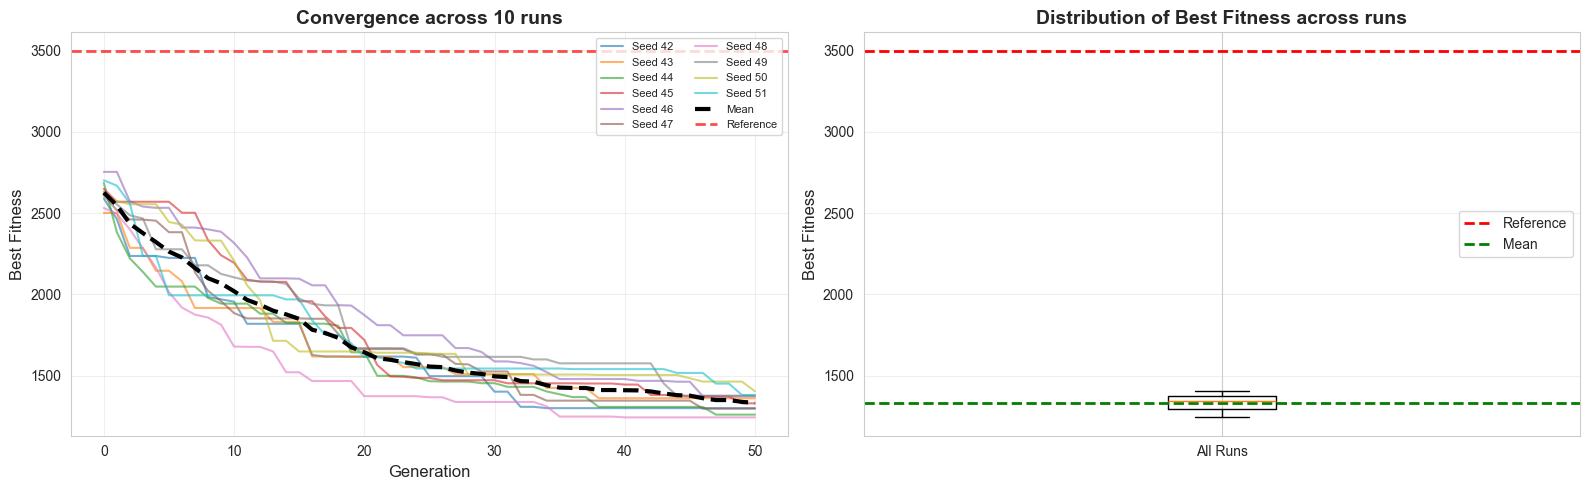

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, result in enumerate(robustness_results):
    axes[0].plot(result['history'], alpha=0.6, linewidth=1.5, label=f"Seed {result['seed']}")

mean_history = np.mean([r['history'] for r in robustness_results], axis=0)
axes[0].plot(mean_history, color='black', linewidth=3, label='Mean', linestyle='--')
axes[0].axhline(y=reference_fitness, color='red', linestyle='--', linewidth=2, label='Reference', alpha=0.7)
axes[0].set_xlabel('Generation', fontsize=12)
axes[0].set_ylabel('Best Fitness', fontsize=12)
axes[0].set_title(f'Convergence across {num_runs} runs', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8, ncol=2)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([r['best_fitness'] for r in robustness_results])
axes[1].axhline(y=reference_fitness, color='red', linestyle='--', linewidth=2, label='Reference')
axes[1].axhline(y=robustness_df['best_fitness'].mean(), color='green', linestyle='--', linewidth=2, label='Mean')
axes[1].set_ylabel('Best Fitness', fontsize=12)
axes[1].set_title('Distribution of Best Fitness across runs', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(['All Runs'])

plt.tight_layout()
plt.show()


## Conclusions

### Key Findings:

1. **Operator Performance**: The grid search systematically evaluated all combinations of crossover, mutation, and selection operators
2. **Hyperparameter Sensitivity**: The analysis shows how mutation and crossover rates affect performance
3. **Reproducibility**: All experiments use a fixed seed (42) for complete reproducibility
4. **Robustness**: The best configuration was tested with 10 different seeds to verify stability

### Experimental Setup:
- Population Size: 30 (balanced between exploration and computational cost)
- Generations: 50 (sufficient for convergence based on literature)
- Random Seed: 42 (ensures reproducibility)
- Total Configurations Tested: 108 (3×3×3×2×2)
- Hyperparameters: Mutation Rates [0.1, 0.2] and Crossover Rates [0.7, 0.8] (literature-optimized values)
- Estimated Runtime: ~3-4 hours

### Notes:
- Results are specific to Function6 with permutation length 20
- The same framework can be applied to other permutation-based problems
- Consider increasing generations or population size for harder problems
- The selected hyperparameter ranges (0.1-0.2 for mutation, 0.7-0.8 for crossover) are based on literature recommendations for permutation problems

## Quick Test Area

Use this area for quick testing and experimentation


FINAL OPTIMIZATION RUN - BEST CONFIGURATION WITH EXTENDED PARAMETERS

Best Configuration from Grid Search:
  Crossover: Order
  Mutation: Inversion
  Selection: Elite
  Mutation Rate: 0.2
  Crossover Rate: 0.7
  Best Seed from Robustness Test: 48 (achieved 1243.92)

Extended Parameters:
  Population Size: 100 (vs 30 in grid search)
  Generations: 200 (vs 50 in grid search)

Running optimization...
Generation 10/200: Best=1433.6844, Avg=1473.0783
Generation 20/200: Best=1200.2270, Avg=1253.4526
Generation 30/200: Best=1165.1804, Avg=1211.6214
Generation 40/200: Best=1159.8762, Avg=1212.3398
Generation 50/200: Best=1159.8762, Avg=1210.0714
Generation 60/200: Best=1159.8762, Avg=1206.5915
Generation 70/200: Best=1159.8762, Avg=1212.8167
Generation 80/200: Best=1159.8762, Avg=1206.8930
Generation 90/200: Best=1159.8762, Avg=1202.9419
Generation 100/200: Best=1159.8762, Avg=1221.3063
Generation 110/200: Best=1159.8762, Avg=1222.6459
Generation 120/200: Best=1159.8762, Avg=1219.4671
Generati

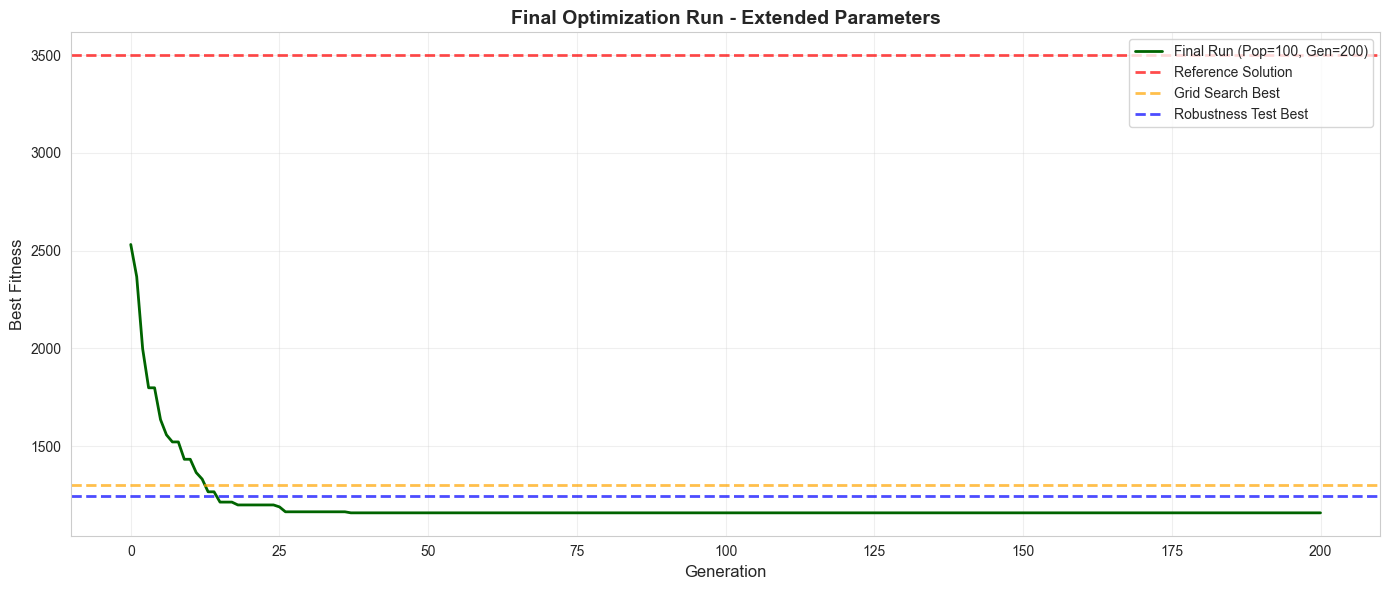


Estimated runtime: ~10-15 minutes


In [82]:
# Final optimization run with best configuration and larger parameters
print("="*80)
print("FINAL OPTIMIZATION RUN - BEST CONFIGURATION WITH EXTENDED PARAMETERS")
print("="*80)
print(f"\nBest Configuration from Grid Search:")
print(f"  Crossover: Order")
print(f"  Mutation: Inversion")
print(f"  Selection: Elite")
print(f"  Mutation Rate: 0.2")
print(f"  Crossover Rate: 0.7")
print(f"  Best Seed from Robustness Test: 48 (achieved 1243.92)")
print(f"\nExtended Parameters:")
print(f"  Population Size: 100 (vs 30 in grid search)")
print(f"  Generations: 200 (vs 50 in grid search)")
print(f"\nRunning optimization...")

final_best_solution, final_best_fitness, final_history = evolutionary_algorithm(
    blackbox=bb,
    population_size=100,
    generations=200,
    mutation_rate=0.2,
    crossover_rate=0.7,
    mutation_operator=inversion_mutation,
    crossover_operator=order_crossover,
    selection_operator=elite_selection,
    seed=48,
    verbose=True
)

print(f"\n{'='*80}")
print("FINAL RESULTS")
print(f"{'='*80}")
print(f"Final Best Fitness: {final_best_fitness:.4f}")
print(f"Reference Fitness: {reference_fitness:.4f}")
print(f"Improvement: {reference_fitness - final_best_fitness:.4f} ({(reference_fitness - final_best_fitness)/reference_fitness*100:.2f}%)")
print(f"Grid Search Best (Pop=30, Gen=50): 1300.79")
print(f"Robustness Test Best (Pop=30, Gen=50, Seed=48): 1243.92")
print(f"This Run (Pop=100, Gen=200, Seed=48): {final_best_fitness:.2f}")
print(f"\nBest Solution Permutation:")
print(final_best_solution)
print(f"{'='*80}")

# Visualization of final run
plt.figure(figsize=(14, 6))
plt.plot(final_history, linewidth=2, color='darkgreen', label=f'Final Run (Pop=100, Gen=200)')
plt.axhline(y=reference_fitness, color='red', linestyle='--', linewidth=2, label='Reference Solution', alpha=0.7)
plt.axhline(y=1300.79, color='orange', linestyle='--', linewidth=2, label='Grid Search Best', alpha=0.7)
plt.axhline(y=1243.92, color='blue', linestyle='--', linewidth=2, label='Robustness Test Best', alpha=0.7)
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Best Fitness', fontsize=12)
plt.title('Final Optimization Run - Extended Parameters', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEstimated runtime: ~10-15 minutes")

In [81]:
# Your code here
